# This is the final code after preprocessing

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from tabulate import tabulate
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import mutual_info_classif

In [3]:
!pip install datasets huggingface_hub

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
#from datasets import load_dataset

from dotenv import load_dotenv
import os

load_dotenv()  # loads .env file

hf_token = os.getenv("HF_TOKEN")

from datasets import load_dataset
dataset = load_dataset("maruuf/CIC-IDS2017", token=hf_token)

print(dataset)


DatasetDict({
    train: Dataset({
        features: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Coun

In [41]:
# Convert the 'train' split of the dataset to a pandas DataFrame
df = dataset['train'].to_pandas()

# Display the first 10 rows of the DataFrame
display(df.head(10))

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
5,54871,1022,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
6,54925,4,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
7,54925,42,1,1,6,6,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
8,9282,4,2,0,12,0,6,6,6.0,0.00000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
9,55153,4,2,0,37,0,31,6,18.5,17.67767,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [43]:
print(tabulate(df.sample(15), headers='keys', tablefmt='grid'))

+---------+---------------------+------------------+----------------------+---------------------------+-------------------------------+--------------------------------+--------------------------+--------------------------+---------------------------+--------------------------+-------------------------+--------------------------+---------------------------+--------------------------+------------------+-------------------+------------------+-----------------+-----------------+-----------------+-----------------+-----------------+----------------+----------------+----------------+-----------------+-----------------+----------------+----------------+----------------+-----------------+------------------+------------------+------------------+----------------------+----------------------+-----------------+------------------+----------------------+----------------------+-----------------------+----------------------+---------------------------+------------------+-------------------+-----------

In [44]:
df.shape

(2830743, 79)

In [45]:
for col in df.columns:
    print(f"'{col}'")

' Destination Port'
' Flow Duration'
' Total Fwd Packets'
' Total Backward Packets'
'Total Length of Fwd Packets'
' Total Length of Bwd Packets'
' Fwd Packet Length Max'
' Fwd Packet Length Min'
' Fwd Packet Length Mean'
' Fwd Packet Length Std'
'Bwd Packet Length Max'
' Bwd Packet Length Min'
' Bwd Packet Length Mean'
' Bwd Packet Length Std'
'Flow Bytes/s'
' Flow Packets/s'
' Flow IAT Mean'
' Flow IAT Std'
' Flow IAT Max'
' Flow IAT Min'
'Fwd IAT Total'
' Fwd IAT Mean'
' Fwd IAT Std'
' Fwd IAT Max'
' Fwd IAT Min'
'Bwd IAT Total'
' Bwd IAT Mean'
' Bwd IAT Std'
' Bwd IAT Max'
' Bwd IAT Min'
'Fwd PSH Flags'
' Bwd PSH Flags'
' Fwd URG Flags'
' Bwd URG Flags'
' Fwd Header Length'
' Bwd Header Length'
'Fwd Packets/s'
' Bwd Packets/s'
' Min Packet Length'
' Max Packet Length'
' Packet Length Mean'
' Packet Length Std'
' Packet Length Variance'
'FIN Flag Count'
' SYN Flag Count'
' RST Flag Count'
' PSH Flag Count'
' ACK Flag Count'
' URG Flag Count'
' CWE Flag Count'
' ECE Flag Count'
' Down

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

In [47]:
df.describe()

C:\Users\Maruf\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
C:\Users\Maruf\AppData\Roaming\Python\Python312\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [48]:
df.corr(numeric_only=True)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Destination Port,1.000000,-0.151680,-0.004236,-0.003947,0.011145,-0.003082,0.097926,-0.045388,0.140220,0.128861,...,-0.003226,0.000897,-0.035562,-0.043717,-0.051859,-0.023194,-0.112585,0.010399,-0.108185,-0.114614
Flow Duration,-0.151680,1.000000,0.020857,0.019670,0.065456,0.016186,0.273308,-0.105230,0.143689,0.234437,...,0.015942,-0.001357,0.189299,0.241060,0.294034,0.121171,0.768034,0.243154,0.779527,0.738328
Total Fwd Packets,-0.004236,0.020857,1.000000,0.999070,0.365508,0.996993,0.009358,-0.002989,0.000032,0.001403,...,0.887387,-0.000184,0.039937,0.008329,0.030459,0.041283,0.001820,0.000809,0.001906,0.001670
Total Backward Packets,-0.003947,0.019670,0.999070,1.000000,0.359451,0.994429,0.009039,-0.002600,-0.000333,0.001026,...,0.882566,0.000018,0.038963,0.006437,0.028602,0.041278,0.001425,0.000492,0.001456,0.001330
Total Length of Fwd Packets,0.011145,0.065456,0.365508,0.359451,1.000000,0.353762,0.197030,-0.000275,0.185262,0.159787,...,0.407448,-0.001209,0.101084,0.103326,0.126493,0.068325,0.022660,0.027064,0.026079,0.018634
Total Length of Bwd Packets,-0.003082,0.016186,0.996993,0.994429,0.353762,1.000000,0.006612,-0.002182,-0.001445,-0.000470,...,0.883967,0.000018,0.035956,0.003493,0.024837,0.039069,0.000809,0.000105,0.000797,0.000789
Fwd Packet Length Max,0.097926,0.273308,0.009358,0.009039,0.197030,0.006612,1.000000,0.006051,0.887503,0.968414,...,0.007558,0.000514,0.124023,0.091053,0.142830,0.105641,0.181135,0.178091,0.199559,0.156973
Fwd Packet Length Min,-0.045388,-0.105230,-0.002989,-0.002600,-0.000275,-0.002182,0.006051,1.000000,0.262902,-0.072424,...,-0.002086,-0.001179,-0.033444,-0.030765,-0.042139,-0.025912,-0.071304,-0.029951,-0.073419,-0.067435
Fwd Packet Length Mean,0.140220,0.143689,0.000032,-0.000333,0.185262,-0.001445,0.887503,0.262902,1.000000,0.893799,...,0.000355,0.000044,0.093249,0.056584,0.093893,0.081170,0.127959,0.178462,0.148402,0.104155
Fwd Packet Length Std,0.128861,0.234437,0.001403,0.001026,0.159787,-0.000470,0.968414,-0.072424,0.893799,1.000000,...,0.001033,0.000573,0.106462,0.068227,0.115480,0.094164,0.183139,0.191278,0.203304,0.157677


In [49]:
pd.set_option('display.max_rows', None)
print(df.isnull().sum())

 Destination Port                  0
 Flow Duration                     0
 Total Fwd Packets                 0
 Total Backward Packets            0
Total Length of Fwd Packets        0
 Total Length of Bwd Packets       0
 Fwd Packet Length Max             0
 Fwd Packet Length Min             0
 Fwd Packet Length Mean            0
 Fwd Packet Length Std             0
Bwd Packet Length Max              0
 Bwd Packet Length Min             0
 Bwd Packet Length Mean            0
 Bwd Packet Length Std             0
Flow Bytes/s                    1358
 Flow Packets/s                    0
 Flow IAT Mean                     0
 Flow IAT Std                      0
 Flow IAT Max                      0
 Flow IAT Min                      0
Fwd IAT Total                      0
 Fwd IAT Mean                      0
 Fwd IAT Std                       0
 Fwd IAT Max                       0
 Fwd IAT Min                       0
Bwd IAT Total                      0
 Bwd IAT Mean                      0
 

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

Flow Bytes/s    1358
dtype: int64


# visualization

C:\Users\Maruf\AppData\Local\Temp\ipykernel_9708\2180686502.py:8: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
C:\Users\Maruf\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.


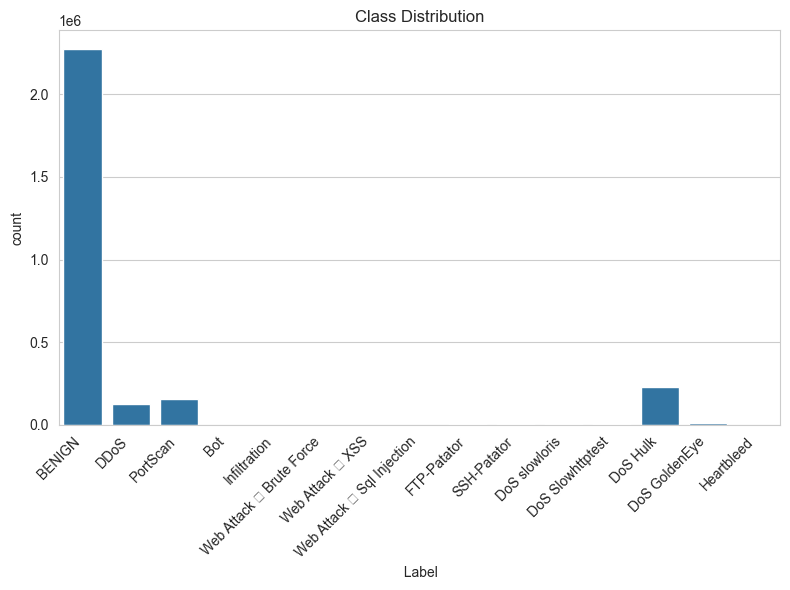

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6)) # Increase figure size
sns.countplot(data=df, x=" Label")
plt.xticks(rotation=45, ha='right') # Adjust rotation and alignment
plt.title("Class Distribution")
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

C:\Users\Maruf\AppData\Local\Temp\ipykernel_9708\2727375492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

C:\Users\Maruf\AppData\Local\Temp\ipykernel_9708\2727375492.py:10: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
C:\Users\Maruf\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.


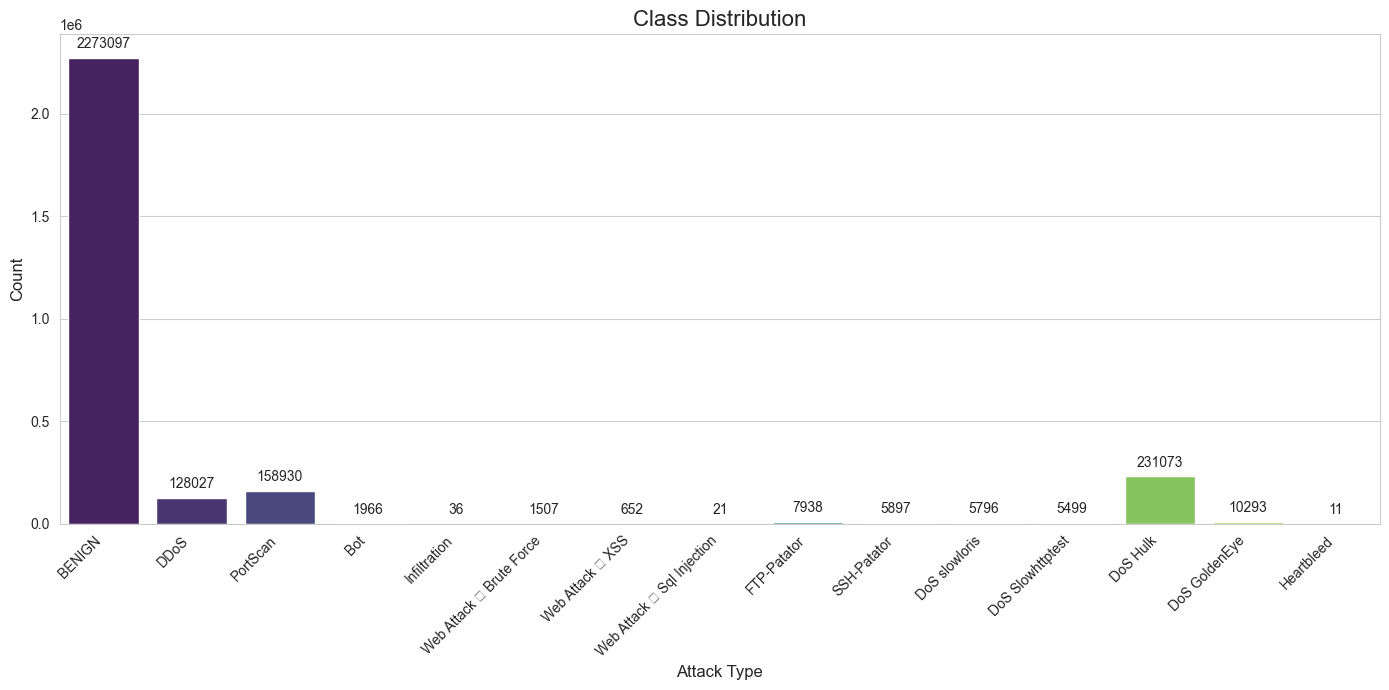

In [52]:

# Set a style for the plot
sns.set_style("whitegrid")

plt.figure(figsize=(14, 7)) # Increase figure size a bit more
ax = sns.countplot(data=df, x=" Label", palette="viridis") # Change color palette
plt.xticks(rotation=45, ha='right') # Adjust rotation and alignment
plt.title("Class Distribution", fontsize=16) # Increase title font size
plt.xlabel("Attack Type", fontsize=12) # Add x-axis label
plt.ylabel("Count", fontsize=12) # Add y-axis label
plt.tight_layout() # Adjust layout to prevent labels from being cut off

# Add count annotations to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=5) # Add padding to labels

plt.show()

# preprocessing

In [53]:

# List of columns to drop
cols_to_drop = [
    " Fwd Header Length.1",
    " act_data_pkt_fwd",
    " min_seg_size_forward",
    "Fwd Avg Bytes/Bulk",
    " Fwd Avg Packets/Bulk",
    " Fwd Avg Bulk Rate",
    " Bwd Avg Bytes/Bulk",
    " Bwd Avg Packets/Bulk",
    "Bwd Avg Bulk Rate"
]

# Drop them safely 
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors="ignore")

print(tabulate(df.head(5), headers='keys', tablefmt='grid'))


+----+---------------------+------------------+----------------------+---------------------------+-------------------------------+--------------------------------+--------------------------+--------------------------+---------------------------+--------------------------+-------------------------+--------------------------+---------------------------+--------------------------+----------------+-------------------+------------------+-----------------+-----------------+-----------------+-----------------+-----------------+----------------+----------------+----------------+-----------------+-----------------+----------------+----------------+----------------+-----------------+------------------+------------------+------------------+----------------------+----------------------+-----------------+------------------+----------------------+----------------------+-----------------------+----------------------+---------------------------+------------------+-------------------+------------------

In [54]:
print("After:", df.shape)

After: (2830743, 70)


In [ ]:
# Define custom missing tokens
missing_tokens = ["", " ", "NA", "N/A", "-", "--", "NULL", "None", "?"]

# Replace custom missing tokens with NaN
df.replace(missing_tokens, np.nan, inplace=True)

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaNs in all numeric columns with their median
for col in df.select_dtypes(include='number').columns:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

# Show first 5 rows in a clean table
print(tabulate(df.tail(10), headers='keys', tablefmt='grid'))
    

+---------+---------------------+------------------+----------------------+---------------------------+-------------------------------+--------------------------------+--------------------------+--------------------------+---------------------------+--------------------------+-------------------------+--------------------------+---------------------------+--------------------------+------------------+-------------------+------------------+------------------+-----------------+-----------------+-----------------+------------------+------------------+----------------+----------------+-----------------+-----------------+----------------+----------------+----------------+-----------------+------------------+------------------+------------------+----------------------+----------------------+-----------------+------------------+----------------------+----------------------+-----------------------+----------------------+---------------------------+------------------+-------------------+-------

In [56]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

Series([], dtype: int64)


In [ ]:
# Save cleaned dataset
#df.to_csv("new_cleaned.csv", index=False)

In [57]:
## remove duplicate columns if any

df = df.loc[:, ~df.columns.duplicated()]  

print("Feature consistency ensured")

Feature consistency ensured


In [58]:
df.shape

(2830743, 70)

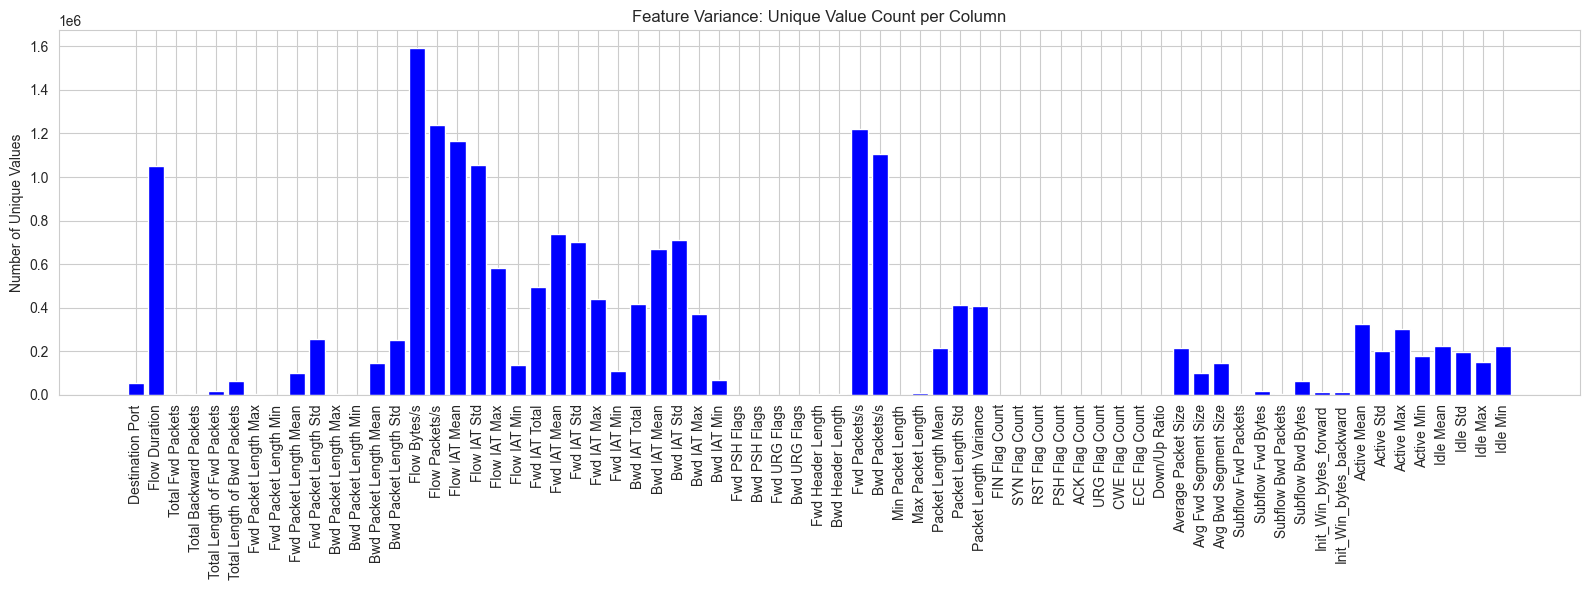

In [ ]:
df.columns = df.columns.str.strip()

# Select numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate number of unique values per column
unique_counts = numeric_df.nunique()

# Plot variance (unique value count)
plt.figure(figsize=(16, 6))
colors = ['red' if unique_counts[col] <= 1 else 'blue' for col in unique_counts.index]
plt.bar(unique_counts.index, unique_counts.values, color=colors)
plt.xticks(rotation=90)
plt.ylabel("Number of Unique Values")
plt.title("Feature Variance: Unique Value Count per Column")
plt.tight_layout()
plt.show()

In [60]:
# A4: Feature Pruning
# Calculate correlation

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Drop features with very low variance or duplicates
low_var_cols = [col for col in numeric_df.columns if numeric_df[col].nunique() <= 1]
df = df.drop(columns=low_var_cols)

print("Feature pruning based on variance/correlation")

Feature pruning based on variance/correlation


In [61]:
df.shape

(2830743, 68)

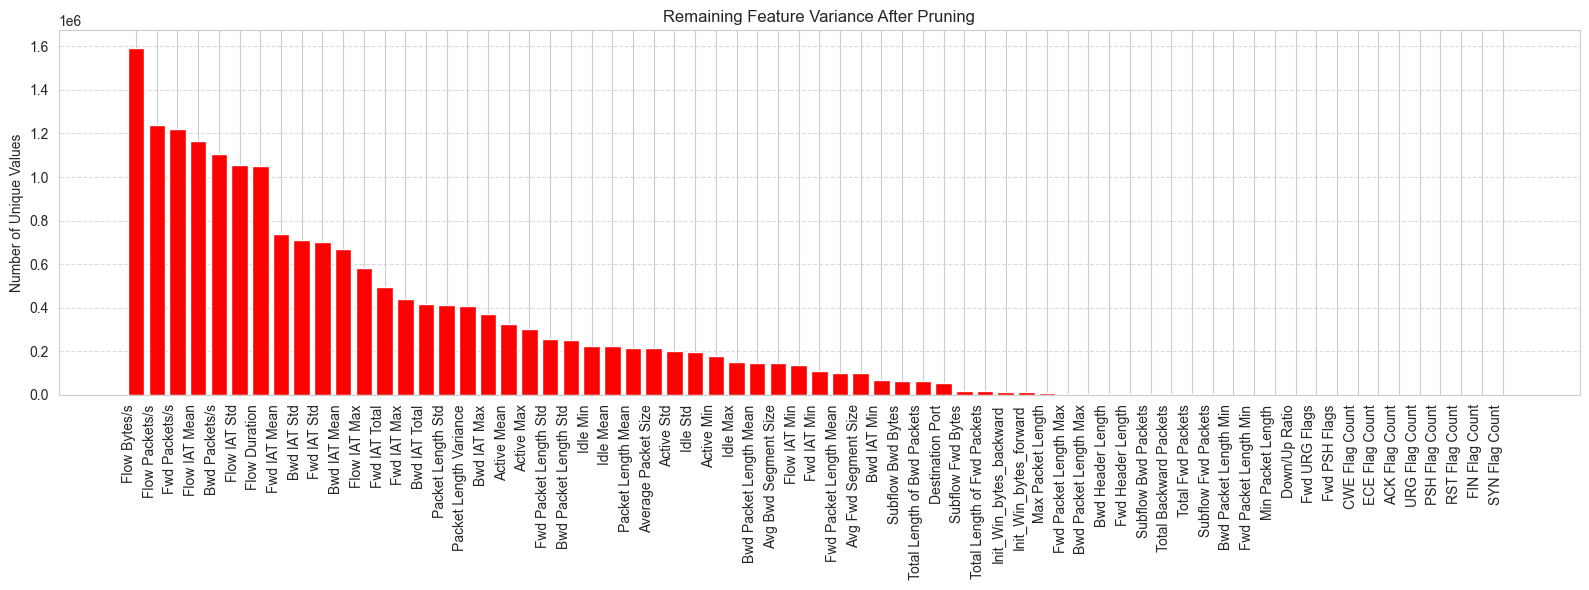

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Select numeric columns and count unique values
numeric_df = df.select_dtypes(include=[np.number])
unique_counts = numeric_df.nunique().sort_values(ascending=False)

# Plot
plt.figure(figsize=(16, 6))
plt.bar(unique_counts.index, unique_counts.values, color='red')
plt.xticks(rotation=90, ha='right')
plt.ylabel("Number of Unique Values")
plt.title("Remaining Feature Variance After Pruning")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Correlation Coefficient

Top 35 Features by Correlation with Target:
PSH Flag Count             0.305413
Min Packet Length          0.254473
Bwd Packet Length Min      0.227019
Fwd IAT Std                0.205842
Idle Mean                  0.187675
Idle Min                   0.187095
Idle Max                   0.186252
Fwd IAT Max                0.182371
Bwd Packet Length Std      0.182160
Flow IAT Max               0.181158
Bwd Packet Length Max      0.171966
Bwd Packet Length Mean     0.158172
Avg Bwd Segment Size       0.158172
Packet Length Variance     0.155879
Flow IAT Std               0.152930
Packet Length Std          0.151829
Max Packet Length          0.149638
URG Flag Count             0.115142
Fwd Packet Length Min      0.115131
Packet Length Mean         0.111318
Bwd Packets/s              0.108456
Average Packet Size        0.107143
Init_Win_bytes_forward     0.101153
FIN Flag Count             0.095890
Avg Fwd Segment Size       0.087053
Fwd Packet Length Mean     0.087053
Destination Port    

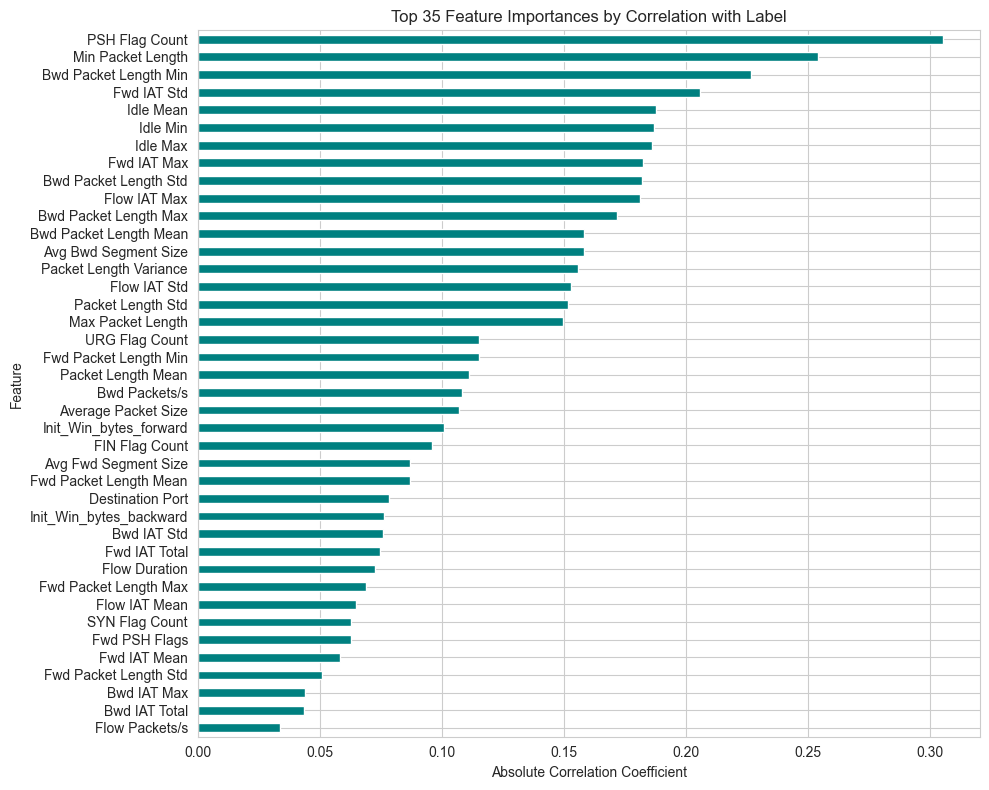

In [34]:

target_col = "Label"  
X = df.drop(columns=[target_col])
y = df[target_col]


# Encode target if it's categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)


# Keep only numeric features
X_num = X.select_dtypes(include=[np.number])


# 2. Compute Correlation

corr_with_target = []
for col in X_num.columns:
    corr = np.corrcoef(X_num[col], y)[0, 1]   # Pearson correlation
    corr_with_target.append(corr)

corr_importances = pd.Series(corr_with_target, index=X_num.columns)


# 3. Show Top Features

print("Top 35 Features by Correlation with Target:")
print(corr_importances.abs().sort_values(ascending=False).head(35))


# 4. Plot Feature Importance

plt.figure(figsize=(10, 8))
corr_importances.abs().sort_values(ascending=False).head(40).plot(kind="barh", color="teal")
plt.title("Top 35 Feature Importances by Correlation with Label")
plt.xlabel("Absolute Correlation Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Decesion Tree

In [32]:
# Define Features & Target
target_col = "Label" 
X = df.drop(columns=[target_col])
y = df[target_col]


# Encode target if categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)


# Keep only numeric features for tree training
X_num = X.select_dtypes(include=[np.number])


# Replace infinite values with NaN and then fill NaN with median
X_num.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in X_num.columns:
    X_num[col] = X_num[col].fillna(X_num[col].median())


# 2. Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_num, y)


# 3. Get Feature Importances
dt_importances = pd.Series(dt.feature_importances_, index=X_num.columns)
print("Top Important Features (Decision Tree):")
print(dt_importances.sort_values(ascending=False).head(36))


Top Important Features (Decision Tree):
Bwd Packet Length Std          0.280234
Average Packet Size            0.174822
Packet Length Std              0.123934
Fwd Packet Length Max          0.109757
Destination Port               0.096207
Flow IAT Std                   0.067272
Flow IAT Mean                  0.033673
Fwd Header Length              0.020962
Init_Win_bytes_forward         0.019015
Subflow Bwd Bytes              0.010004
PSH Flag Count                 0.007849
Flow IAT Min                   0.007222
Total Length of Bwd Packets    0.007010
Fwd IAT Min                    0.006964
Init_Win_bytes_backward        0.006879
Bwd IAT Mean                   0.003689
Bwd Packets/s                  0.003264
Bwd Packet Length Mean         0.003057
Fwd IAT Std                    0.002732
Active Std                     0.001844
Bwd IAT Std                    0.001782
Flow Duration                  0.001651
Total Length of Fwd Packets    0.001547
Fwd Packet Length Mean         0.001421


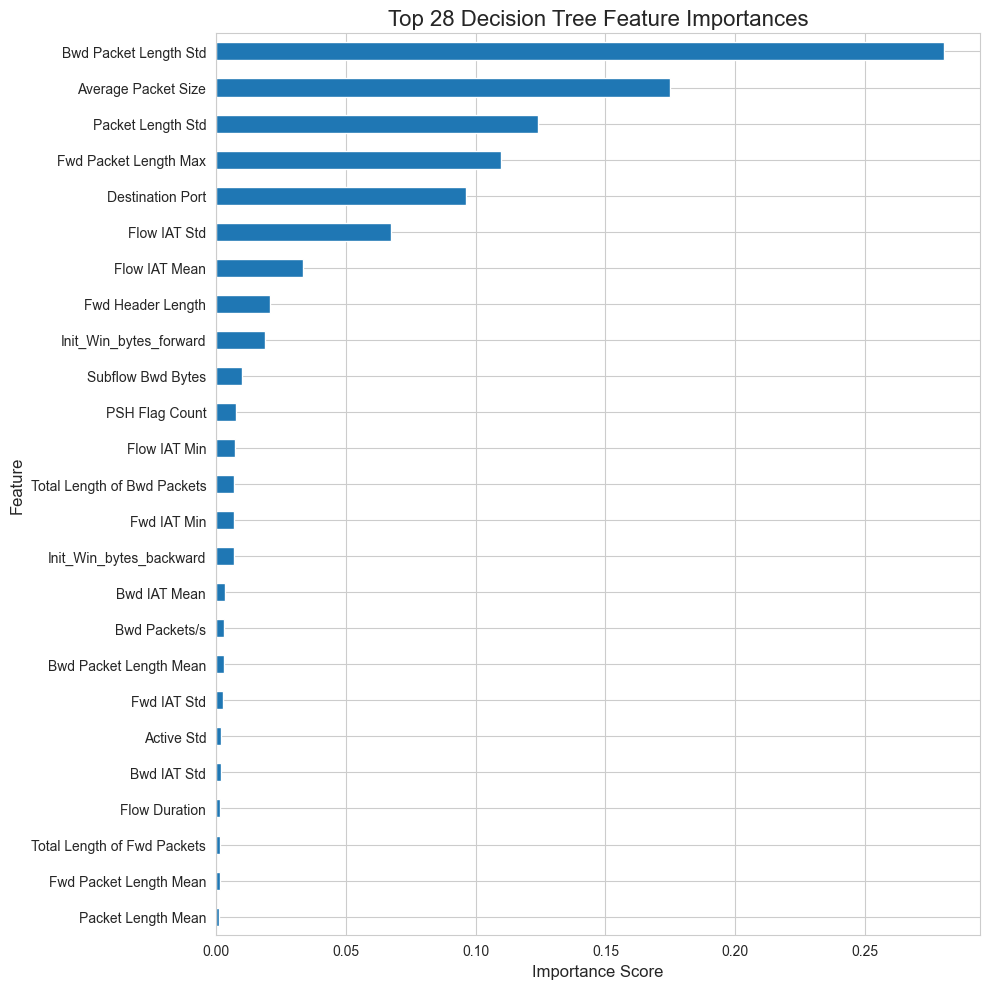

In [35]:
# 4. Filter and sort the top 28 features
top_28_importances = dt_importances.sort_values(ascending=False).head(25)

plt.figure(figsize=(10, 10))
top_28_importances.plot(kind="barh")

plt.title("Top 28 Decision Tree Feature Importances", fontsize=16)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

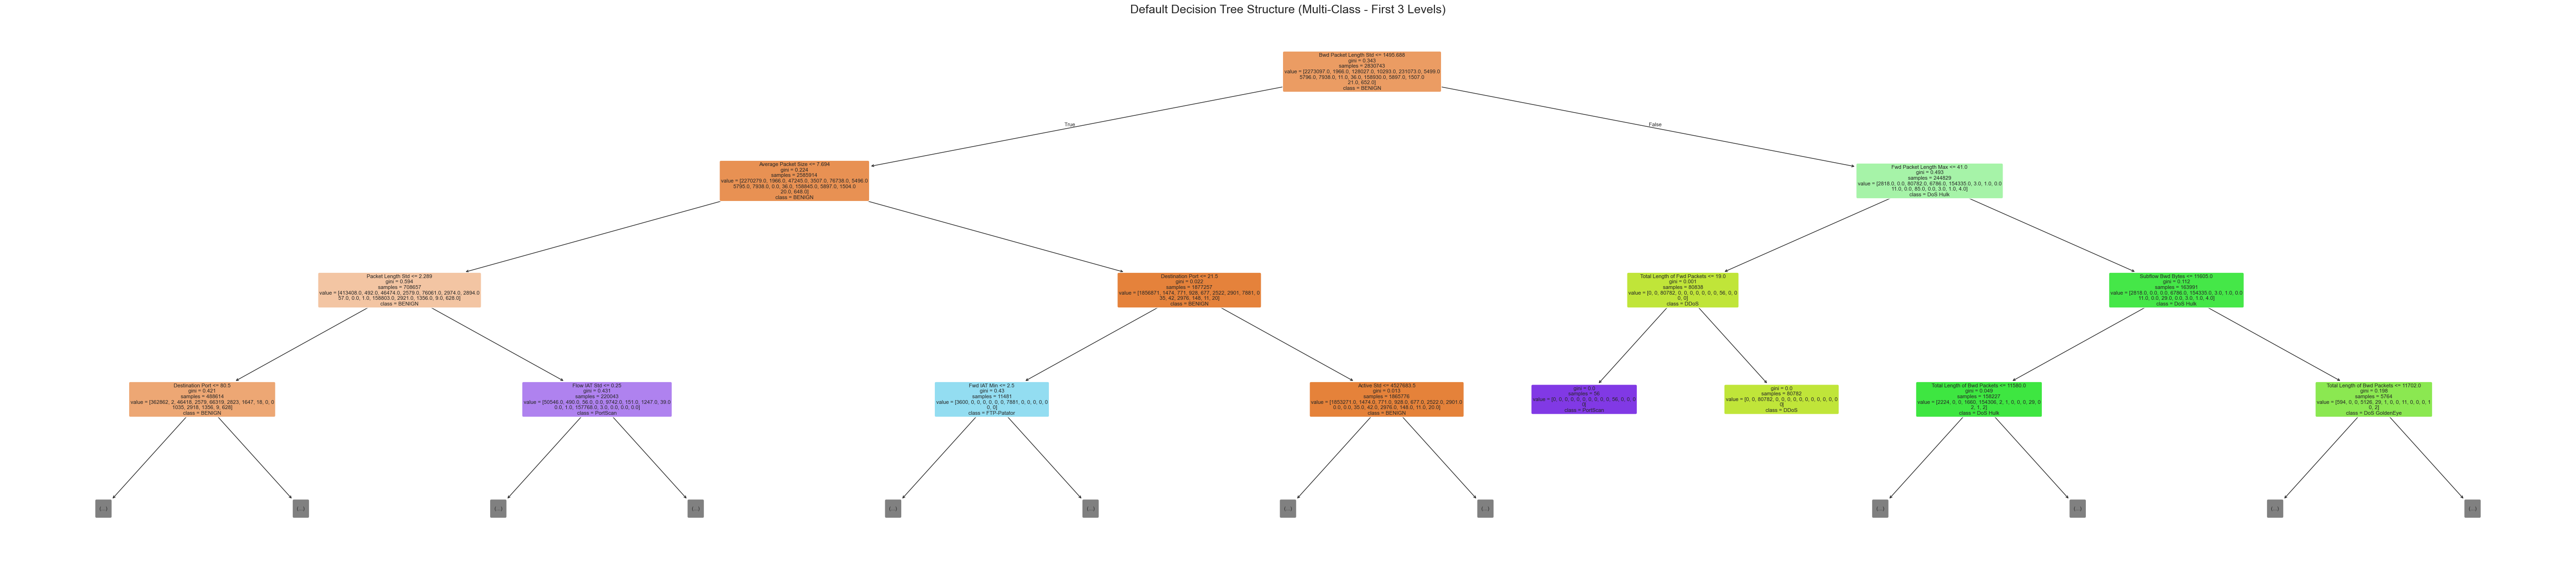

In [71]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 🚨 IMPORTANT: This list must exactly match the alphabetical order of your 15 classes.
CLASS_LABELS_MULTICLASS = [
    "BENIGN", 
    "Bot", 
    "DDoS", 
    "DoS GoldenEye", 
    "DoS Hulk", 
    "DoS Slowhttptest", 
    "DoS slowloris", 
    "FTP-Patator", 
    "Heartbleed", 
    "Infiltration", 
    "PortScan", 
    "SSH-Patator", 
    "Web Attack – Brute Force", 
    "Web Attack – Sql Injection", 
    "Web Attack – XSS"
]

# --- Configuration ---
# CRITICAL: Limit the depth for readability. Do NOT exceed 5 for complex trees.
VIEW_MAX_DEPTH = 3 

# Assuming X_num is your cleaned feature DataFrame from your previous code block
feature_names = X_num.columns.tolist()

plt.figure(figsize=(70, 15)) # Use a very large figure size for visualization

plot_tree(
    dt, # Your trained default Decision Tree model
    feature_names=feature_names, 
    class_names=CLASS_LABELS_MULTICLASS,
    filled=True,                     # Color nodes based on the majority class
    rounded=True,                    # Use rounded boxes
    fontsize=8,                      # Smaller font helps fit the many classes
    max_depth=VIEW_MAX_DEPTH         # Only show the initial, most important splits
)


plt.title(f"Default Decision Tree Structure (Multi-Class - First {VIEW_MAX_DEPTH} Levels)", fontsize=18)
plt.show()

Target converted to Binary Target (0=BENIGN, 1=ATTACK).
Tuning Sample Size: 283074 rows.

Starting Hyperparameter Tuning on Binary Target (may take a few minutes)...


C:\Users\Maruf\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
8 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Maruf\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Maruf\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Maruf\AppData\Roaming\Python\Python312\site-pa

Tuning Complete. Best Model Found.


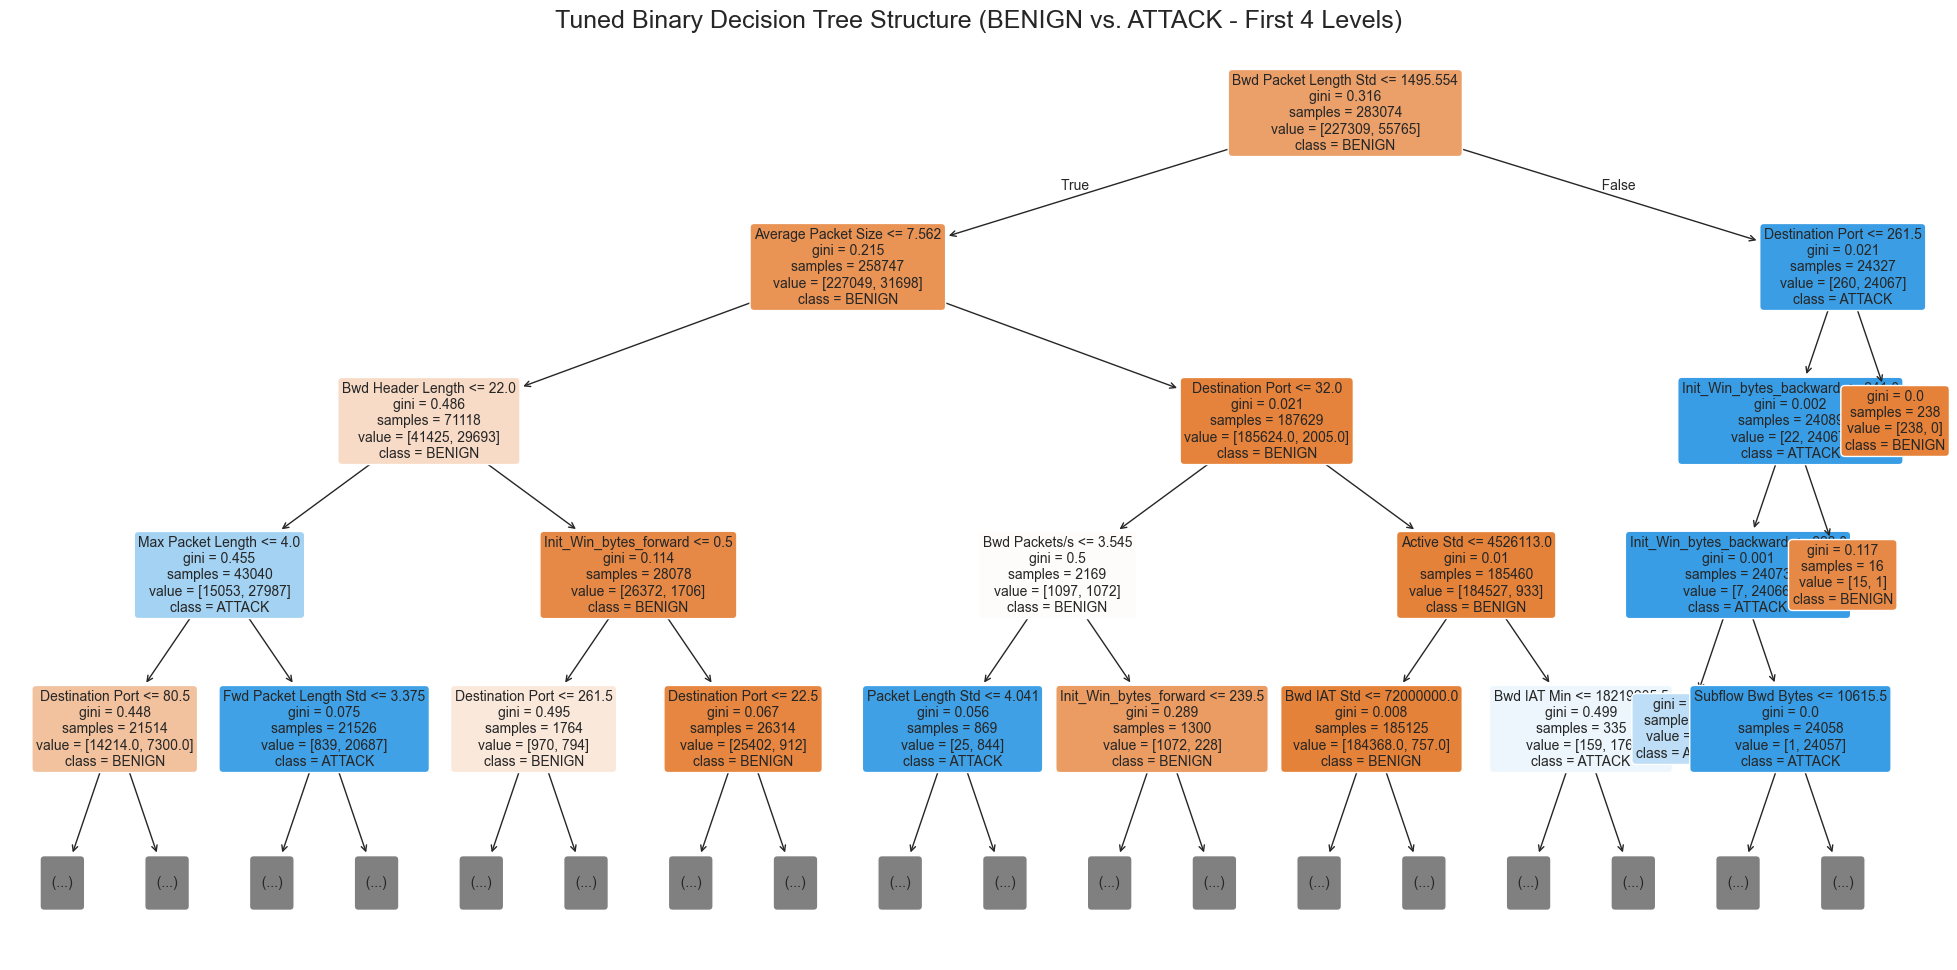

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

# --- Configuration ---
RANDOM_SEED = 42
SAMPLE_SIZE = 0.1 # Use 10% of the data for fast tuning

# --- 1. Binary Encoding and Sampling (Preparation) ---

# Map target to binary (Assuming BENIGN was encoded as 0, all others are 1)
y_binary = np.where(y_encoded != 0, 1, 0)
print(f"Target converted to Binary Target (0=BENIGN, 1=ATTACK).")

# Stratified Sampling with Binary Target (X_tune_b, y_tune_b)
X_tune_b, _, y_tune_b, _ = train_test_split(
    X_num, 
    y_binary, 
    test_size=(1 - SAMPLE_SIZE), 
    random_state=RANDOM_SEED, 
    stratify=y_binary 
)
print(f"Tuning Sample Size: {X_tune_b.shape[0]} rows.")

# --- 2. Hyperparameter Tuning and Training ---

# Define the parameter distribution space
param_dist = {
    'max_depth': randint(10, 30),
    'min_samples_split': randint(10, 100),
    'min_samples_leaf': randint(5, 50),
}

# Setup Randomized Search
random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_SEED),
    param_distributions=param_dist,
    n_iter=20,          
    scoring='accuracy', 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,          
    random_state=RANDOM_SEED,
    verbose=0
)

print("\nStarting Hyperparameter Tuning on Binary Target (may take a few minutes)...")
random_search.fit(X_tune_b, y_tune_b)

# Get the best binary estimator
dt_best_binary = random_search.best_estimator_
print("Tuning Complete. Best Model Found.")

# --- 3. Simplified Decision Tree Plotting ---

# Simple class names for the binary plot
BINARY_CLASS_LABELS = ["BENIGN", "ATTACK"] 
VIEW_MAX_DEPTH = 4 # Limit the depth for maximum readability

plt.figure(figsize=(25, 12)) 

plot_tree(
    dt_best_binary, 
    feature_names=X_num.columns.tolist(), 
    class_names=BINARY_CLASS_LABELS,
    filled=True,                     
    rounded=True,                    
    fontsize=10,                     
    max_depth=VIEW_MAX_DEPTH         
)


plt.title(f"Tuned Binary Decision Tree Structure (BENIGN vs. ATTACK - First {VIEW_MAX_DEPTH} Levels)", fontsize=18)
plt.show()

## ANOVA F-test Feature Importance and Mutual Information Feature Importance


Top 35 Features (ANOVA):
Bwd Packet Length Std     180643.254043
Bwd Packet Length Mean    167942.348296
Avg Bwd Segment Size      167942.348296
Bwd Packet Length Max     164881.247113
Packet Length Std         150042.978884
Fwd IAT Std               143373.828121
Max Packet Length         132493.349872
Packet Length Variance    130371.777905
Idle Min                  122428.234711
Idle Mean                 121926.094584
Average Packet Size       118551.296432
Packet Length Mean        116639.534356
Idle Max                  115832.332950
Flow IAT Max              111954.050147
Fwd IAT Max               111653.753075
Flow IAT Std               75548.543662
PSH Flag Count             42654.990329
Fwd IAT Total              37901.121197
Flow Duration              37384.114241
FIN Flag Count             29320.128545
Flow IAT Mean              23202.987410
Bwd IAT Std                22249.976808
Min Packet Length          20786.124496
ACK Flag Count             20497.325596
Active Min    

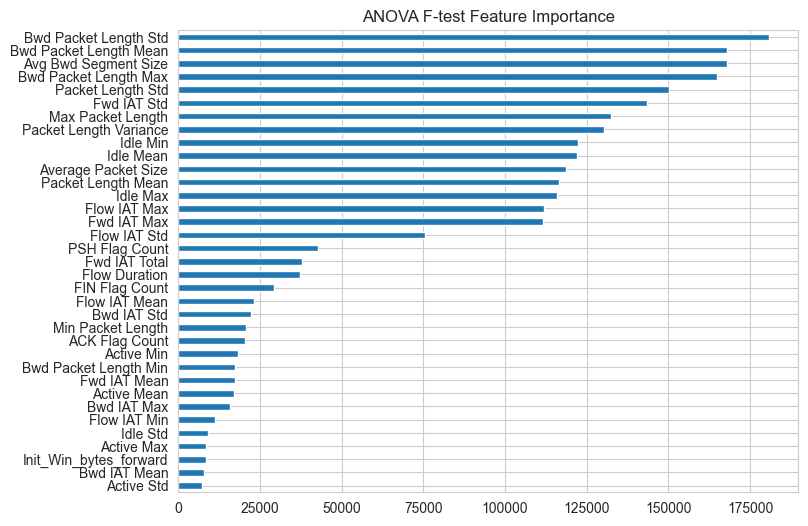

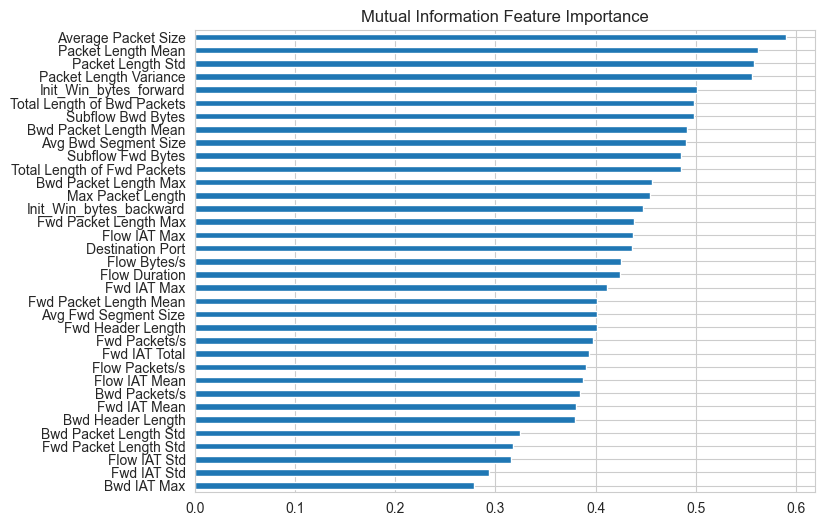

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif, mutual_info_classif, SelectKBest
import matplotlib.pyplot as plt

# --------------------------
# 1. Features & Target
# --------------------------
target_col = "Label"
X = df.drop(columns=[target_col])
y = df[target_col]

# Encode target if categorical
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

# Keep numeric features only
X_num = X.select_dtypes(include=[np.number])

# Handle inf/NaN
X_num = X_num.replace([np.inf, -np.inf], np.nan).fillna(X_num.median())

# Drop constant features
X_num = X_num.loc[:, X_num.nunique() > 1]

# --------------------------
# 2. ANOVA F-test
# --------------------------
anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(X_num, y)
anova_scores = pd.Series(anova_selector.scores_, index=X_num.columns)

# --------------------------
# 3. Mutual Information
# --------------------------
mi_selector = SelectKBest(score_func=mutual_info_classif, k='all')
mi_selector.fit(X_num, y)
mi_scores = pd.Series(mi_selector.scores_, index=X_num.columns)

# --------------------------
# 4. Display Results
# --------------------------
print("\nTop 35 Features (ANOVA):")
print(anova_scores.sort_values(ascending=False).head(35))

print("\nTop 35 Features (Mutual Information):")
print(mi_scores.sort_values(ascending=False).head(35))

# Plot ANOVA
anova_scores.sort_values(ascending=False).head(35).plot(kind="barh", figsize=(8,6))
plt.title("ANOVA F-test Feature Importance")
plt.gca().invert_yaxis()
plt.show()

# Plot MI
mi_scores.sort_values(ascending=False).head(35).plot(kind="barh", figsize=(8,6))
plt.title("Mutual Information Feature Importance")
plt.gca().invert_yaxis()
plt.show()


# XGBoost Feature Importance

C:\Users\Maruf\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [02:14:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Top 20 Features (XGBoost):
Bwd Packet Length Std          0.130798
Idle Mean                      0.113596
Bwd Packet Length Mean         0.110038
PSH Flag Count                 0.102842
Average Packet Size            0.070662
Bwd Header Length              0.047843
Max Packet Length              0.043070
Bwd Packets/s                  0.039641
Total Length of Fwd Packets    0.037556
Fwd IAT Std                    0.032918
Fwd Packet Length Min          0.031151
Total Backward Packets         0.028576
Total Fwd Packets              0.021570
Flow IAT Std                   0.021471
Flow Bytes/s                   0.019378
FIN Flag Count                 0.017586
Total Length of Bwd Packets    0.016596
Fwd Packet Length Max          0.012866
Active Std                     0.012628
Destination Port               0.012335
dtype: float32


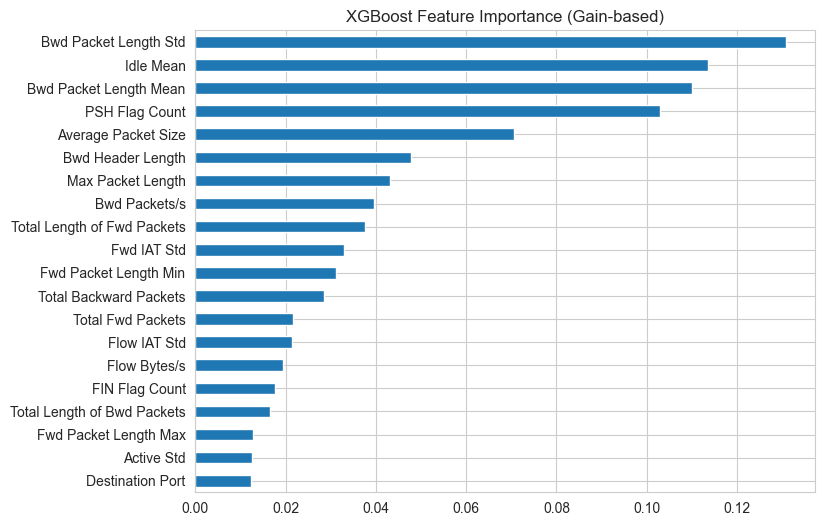

In [29]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_num, y, test_size=0.2, random_state=42, stratify=y)

# Train XGBoost model
xgb_clf = xgb.XGBClassifier(
    n_estimators=200, 
    max_depth=6, 
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)
xgb_clf.fit(X_train, y_train)

# Get importance
xgb_importances = pd.Series(xgb_clf.feature_importances_, index=X_num.columns)

print("\nTop 20 Features (XGBoost):")
print(xgb_importances.sort_values(ascending=False).head(20))

# Plot
xgb_importances.sort_values(ascending=False).head(20).plot(kind="barh", figsize=(8,6))
plt.title("XGBoost Feature Importance (Gain-based)")
plt.gca().invert_yaxis()
plt.show()


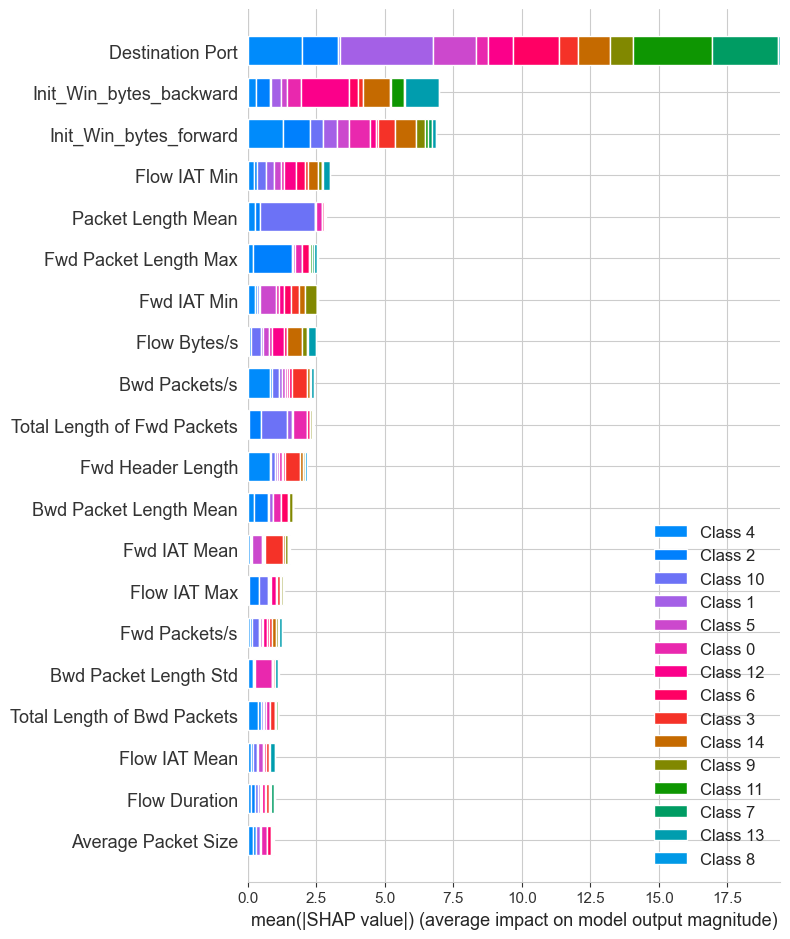

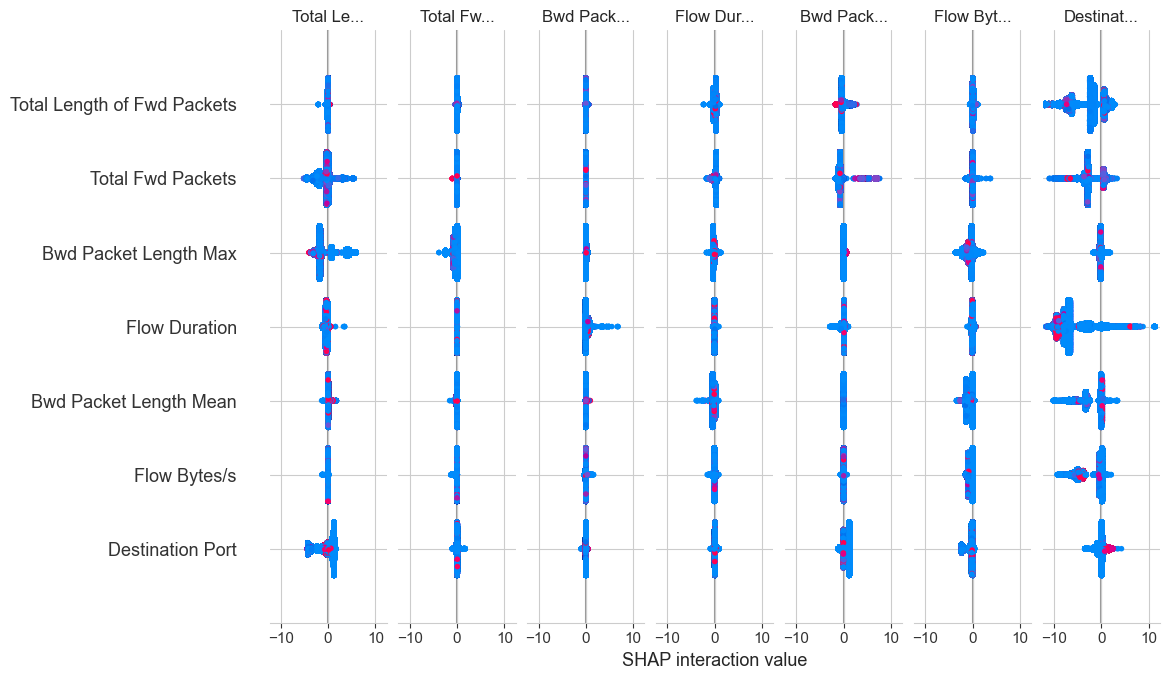

In [30]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test)

# Summary Plot (Top Global Features)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Detailed SHAP Summary (Beeswarm)
shap.summary_plot(shap_values, X_test)
